Домашнее задание "Классификация: Логистическая регрессия и SVM"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model, preprocessing, model_selection, svm

data_raw = pd.read_csv('adult.csv')
data_raw.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


Удалим пустые значения, предварительно обозначим '?' как пустое значение.

In [3]:
data = data_raw.replace('?', None)
#data = data_raw.dropna()
data = data[data[data.columns].notnull().all(1)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              45222 non-null  int64 
 1   workclass        45222 non-null  object
 2   fnlwgt           45222 non-null  int64 
 3   education        45222 non-null  object
 4   educational-num  45222 non-null  int64 
 5   marital-status   45222 non-null  object
 6   occupation       45222 non-null  object
 7   relationship     45222 non-null  object
 8   race             45222 non-null  object
 9   gender           45222 non-null  object
 10  capital-gain     45222 non-null  int64 
 11  capital-loss     45222 non-null  int64 
 12  hours-per-week   45222 non-null  int64 
 13  native-country   45222 non-null  object
 14  income           45222 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.5+ MB


In [4]:
data.nunique()

age                   74
workclass              7
fnlwgt             26741
education             16
educational-num       16
marital-status         7
occupation            14
relationship           6
race                   5
gender                 2
capital-gain         121
capital-loss          97
hours-per-week        96
native-country        41
income                 2
dtype: int64

**Попробуем понять являются ли признаки education и educational_num одной и той же характеристикой.**

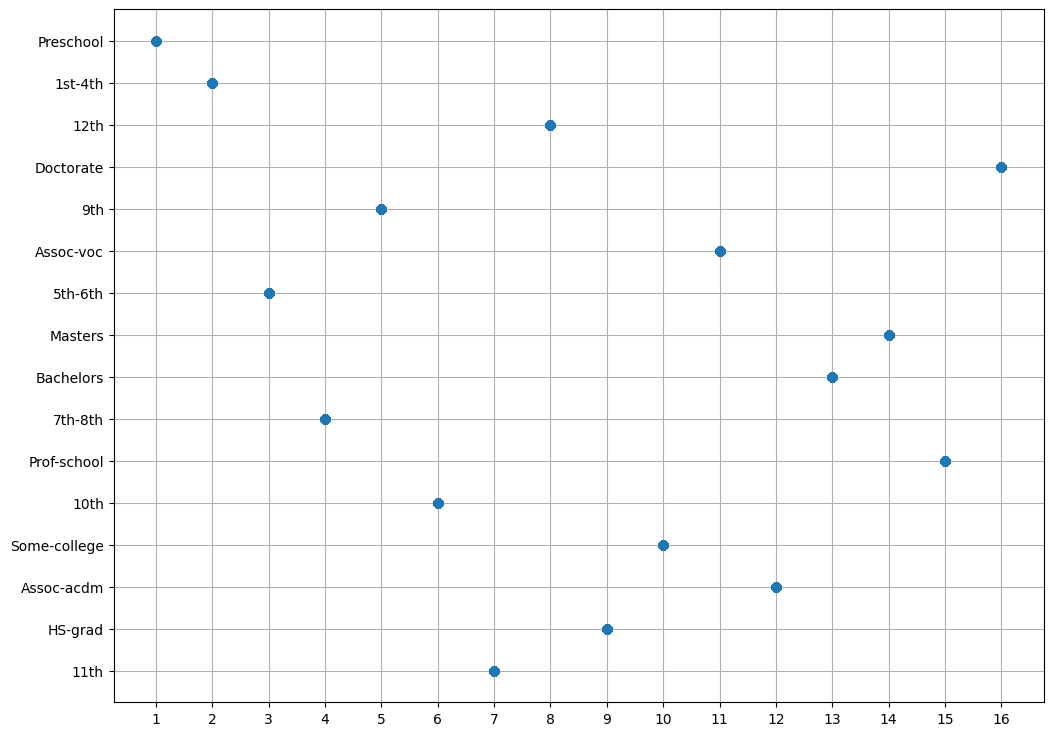

In [5]:
plt.figure(figsize=(12,9))
plt.yticks(np.arange(0, 17, 1))
plt.xticks(np.arange(0, 17, 1))
plt.grid()
plt.plot(data['educational-num'], data['education'], 'o', color='C0')
plt.show()

Education и educational_num являются по сути одним и тем же признаком.
Будем иметь это в виду при выборе признаков для обучения модели. Судя по интерпретации чисел,  признак educational_num можно корректно сравнивать математически.

**Посмотрим визуально на значения признака capital-loss:**

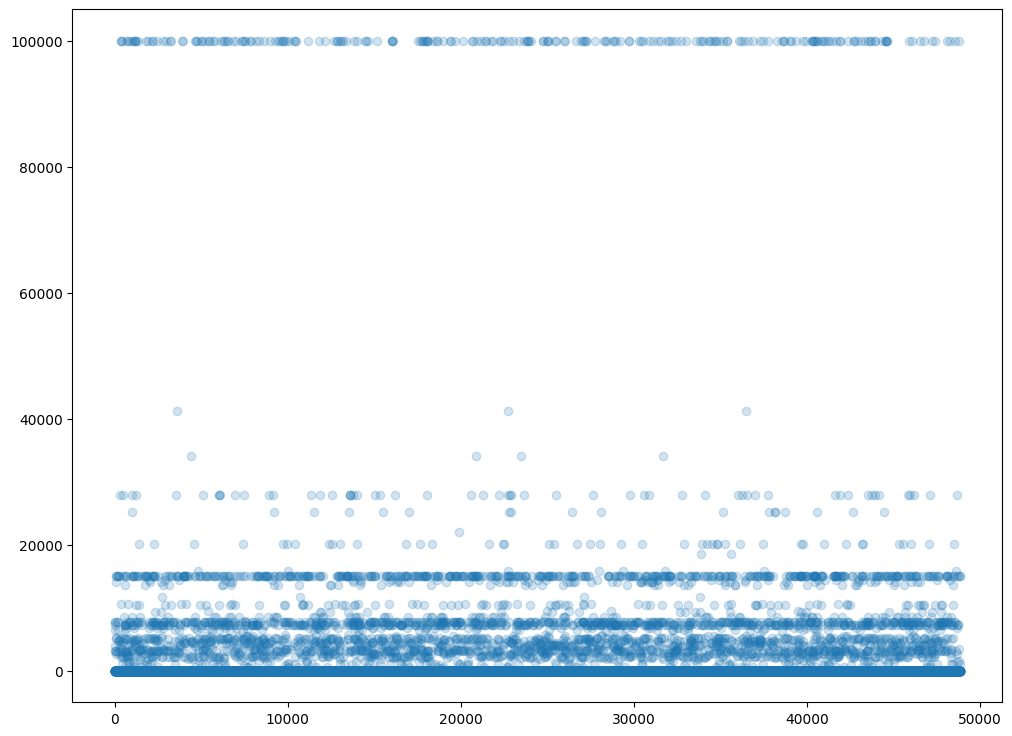

In [6]:
plt.figure(figsize=(12,9))
plt.plot(data['capital-gain'], 'o', alpha=0.2)
plt.show()

Кажется, что большое число значений признака capital-loss в выборке равно нулю.
Оценим сколько (заодно и capital-gain):

In [7]:
zero_capital_gain_count = data['capital-gain'].value_counts().get(0, 0)
print(zero_capital_gain_count)
zero_capital_loss_count = data['capital-loss'].value_counts().get(0, 0)
print(zero_capital_loss_count)

41432
43082


Подавляющее количество значений признаков в выборке равно нулю. Не будем использовать эти признаки в обучении модели.

**Подготовим данные, закодируем категориальные признаки.**

In [23]:
#category_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']

selectedColumns = data[ [ 'age', 'educational-num', 'marital-status', 'workclass', 'hours-per-week' ] ]

X = pd.get_dummies( selectedColumns, columns = [ 'marital-status', 'workclass' ] )

le = preprocessing.LabelEncoder()
le.fit(data['income'])

y = pd.Series( data = le.transform( data['income'] ) )
y.head()

0    0
1    0
2    1
3    1
4    0
dtype: int64

**Разделим данные на тестовые и тренировочные выборки**

In [9]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

**Обучим модель логистической регрессии**

In [10]:
lr_model = linear_model.LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train )

LogisticRegression(max_iter=1000)

In [11]:
lr_model.predict(X_test)

array([0, 0, 1, ..., 0, 0, 0], shape=(9045,))

In [12]:
lr_model.score(X_test, y_test)

0.8233278054173576

**Обучим модель опорных векторов**

In [13]:
svm_model = svm.SVC()
svm_model.fit(X_train, y_train )

SVC()

In [14]:
svm_model.predict(X_test)
svm_model.score(X_test, y_test)

KeyboardInterrupt: 

**Выводы**:
- Были проанализированны исходные данные, были удалены пустые значения, заметил, что множество значений заменено на '?', их тоже интерпретировал как "нет значения" и удалил вхождения соответствующих строк из выборки.
- Также были найдены взаимосвязанные признаки, один из признаков (education) не стал рассматривать как кандидата для обучения.
- Выяснилось, что некоторые признаки ('capital-gain', 'capital-loss') в подавляющем большинстве имеют одинкаовое значение 0. По смыслу признака - это скорее всего тоже отсутствие данных, эти признаки также исключил. Вообще подумалось, наверное надо сначала оценивать признаки, а потом удалять строки с nan и прочими "плохими" значениями - есть вероятность, что посчитав весь признак бесполезным, меньше данных удалится из-за пустых значений.
- Выделили тестовую и обучающую выборки. Провели обучение.
- Выяснил, что раса не вдияет на доход, учет пола даже ухудшает результаты, пока не смог это осознать. Количество часов почти не влияет. Использование educational-num как сравниваемого признака дает немного лучше результат, чем использование его же в виде категориального признака и ощутимо быстрее, что логично, ведь если считать его категориальным, то добавляется 15 признаков.
- SVM классификация немного точнее, но ощутимо дольше.